Run synchrotron 

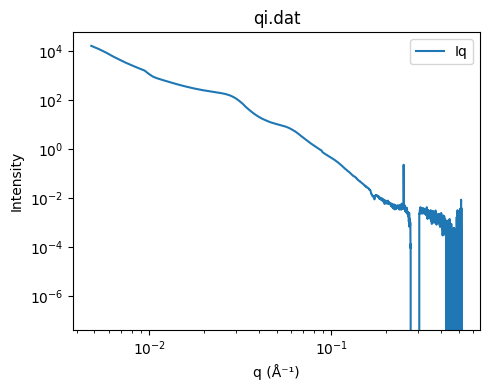

In [10]:
import os
from saxs_analysis3 import *


''' A voir comment on importe les fichiers ici architecture
 -> Dir_path
    -> Sample Name ( Aiguilles, capilaires...)
        -> type ( integration ou radial profile)

Si jamais cette architecture n'est pas bonne changer load sec


'''

#dir_path = r'C:/Users/manip_nco/Documents/Synchrotron_SWING_Fev26\SAXSProcessor-h5file_mapdata'

dir_path = './Synchrotron'
sample_name = 'name'
type = 'integrations'




batch = SAXSBatch(
    dir_path=dir_path,
    sample_name=sample_name,
    type = type,
    file_patern='*',
    sort_key=None  )

batch.loadseq()
#print(batch.experiments)
batch.plot( subplot=True, curves=(['Iq'],),  plot_type=('loglog'), legend=(True,))


[feat_power_law] fallback → cancel_power_law (only 0-dimensional arrays can be converted to Python scalars)
qi.dat | order=2.9591690841278546 | Imin=None


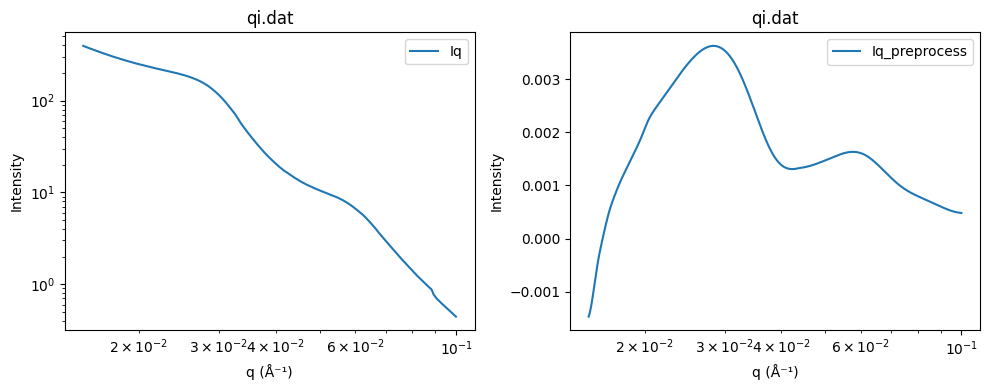

In [11]:
fenetre= (0.015, 0.10) 
# fenetre= (0.020, 0.20) Pour théo
lissage = 40
(batch
.preprocess
.savgol(window=lissage)
.up_scale()
.feat_power_law(average=False, bounds=fenetre, verbose=False) # mettre verbose pour afficher les debugg plot
)

batch.apply_masks(*fenetre)

batch.plot( subplot=True, curves=(['Iq'], ['Iq_preprocess']), peaks=True, plot_type=('loglog', 'semilogx'), legend=(True, True))

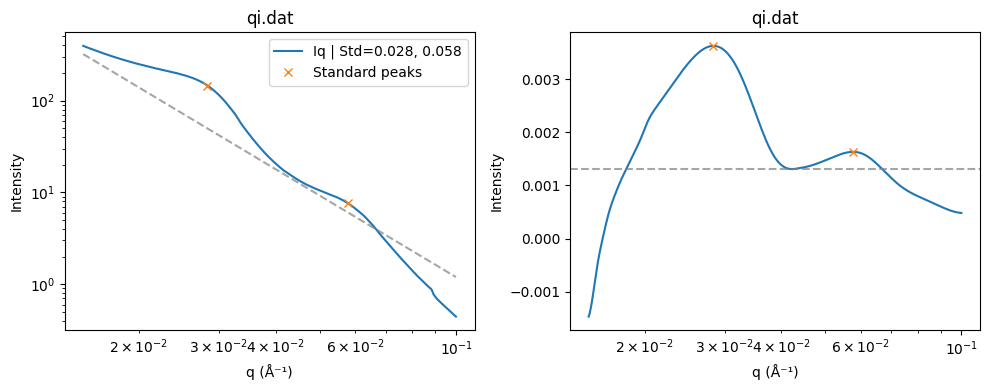

In [12]:
(batch
.findpeaks
.standard()
)

batch.plot( subplot=True, curves=(['Iq'], ['Iq_preprocess']), peaks=True, plot_type=('loglog', 'semilogx'), legend=(True, False))


In [5]:

import pandas as pd
import numpy as np


rows = []

for key, exp in batch.experiments.items():
    name = exp.name

    order_bg = exp.metadata['power_law_order'] 

    # --- Pics ---
    if "Standard" not in exp.peaks:
        print(f"[SKIP] {name} → no Standard peaks")
        continue

    q_peaks = exp.peaks["Standard"].get("q_values", [])

    if len(q_peaks) == 0:
        print(f"[SKIP] {name} → no peaks detected")
        continue

    # --- Ligne Excel ---
    row = {
        #"fenetre": fenetre,
        "Nom fichier": name,

        "q Pic 1": q_peaks[0],
        "ordre background": order_bg,
        "distance (nm)": 2 * np.pi / (q_peaks[0] * 10)
    }

    rows.append(row)

# --- DataFrame final ---
df = pd.DataFrame(rows)
df

,Nom fichier,q Pic 1,ordre background,distance (nm)
0,qi.dat,0.028322,2.959169,22.184623
